start

In [166]:
import operator
from typing import TypedDict, List, Annotated

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_core.messages import SystemMessage, HumanMessage

In [167]:
from pydantic import BaseModel, Field   # pydantic use cause data validation and parsing

class Task(BaseModel):
    id: int 
    title: str
    brief: str = Field(..., description="What to cover")

In [168]:
class Plan(BaseModel):
    blog_title: str
    tasks: List[Task]

In [169]:
class State(TypedDict):
    topic: str
    plan: Plan
    # reducer: results from workers get concatenated automatically
    sections: Annotated[List[str], operator.add]
    final: str


In [170]:
from langchain_google_genai import ChatGoogleGenerativeAI


llm = ChatGoogleGenerativeAI(
   model="gemini-3.1-flash-lite"
)


Orchestrator - create plan

In [171]:
def orchestrator(state: State) -> dict:
    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 5-7 sections on the following topic."
                )
            ),
            HumanMessage(content=f"Topic: {state['topic']}"),
        ]
    )
    return {"plan": plan}


worker

In [172]:
def fanout(state: State):
    return [Send("worker", {"task": task, "topic": state["topic"], "plan": state["plan"]})
            for task in state["plan"].tasks]

In [ ]:
def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]

    blog_title = plan.blog_title

    response = llm.invoke(
        [
            SystemMessage(content="Write one clean Markdown section."),
            HumanMessage(
                content=(
                    f"Blog: {blog_title}\n"
                    f"Topic: {topic}\n\n"
                    f"Section: {task.title}\n"
                    f"Brief: {task.brief}\n\n"
                    "Return only the section content in Markdown."
                )
            ),
        ]
    )

    # 🔥 SAFE HANDLING (MAIN FIX)
    section_md = response.content

    if isinstance(section_md, list):
        section_md = "\n".join(section_md)

    section_md = section_md.strip()

    return {"sections": [section_md]}

Reducer

In [174]:
import re
from pathlib import Path

def reducer(state: State) -> dict:
    
    title = state["plan"].blog_title
    body = "\n\n".join(state["sections"]).strip()

    final_md = f"# {title}\n\n{body}\n"

    # ---- save to file ----
    #Remove illegal characters (like : / \ *) from the title
    safe_title = re.sub(r'[^\w\s-]', '', title)
    filename = safe_title.lower().replace(" ", "_") + ".md"
    
    # FIX 2: Explicitly tie the file to the current working directory
    output_path = Path.cwd() / filename
    
    output_path.write_text(final_md, encoding="utf-8")

    return {"final": final_md}

end -> StateGraph

In [175]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)


In [176]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)


app = g.compile()



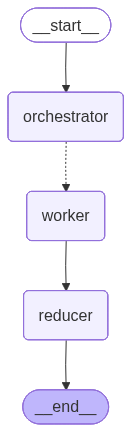

In [177]:
app

In [178]:
out = app.invoke({"topic": "Write a blog on Self Attention", "sections": []})

AttributeError: 'list' object has no attribute 'strip'